# Used Car Price Prediction

## 1) Problem statement.

* This dataset comprises used cars sold on cardehko.com in India as well as important features of these cars.
* If user can predict the price of the car based on input features.
* Prediction results can be used to give new seller the price suggestion based on market condition.

## 2) Data Collection.
* The Dataset is collected from scrapping from cardheko webiste
* The data consists of 13 column and 15411 rows.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df = pd.read_csv('../Datasets/cardekho_imputated.csv', index_col=0)

In [82]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [83]:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [84]:
df.duplicated().value_counts()

False    15244
True       167
Name: count, dtype: int64

In [85]:
df.drop_duplicates(inplace=True)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15244 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15244 non-null  object 
 1   brand              15244 non-null  object 
 2   model              15244 non-null  object 
 3   vehicle_age        15244 non-null  int64  
 4   km_driven          15244 non-null  int64  
 5   seller_type        15244 non-null  object 
 6   fuel_type          15244 non-null  object 
 7   transmission_type  15244 non-null  object 
 8   mileage            15244 non-null  float64
 9   engine             15244 non-null  int64  
 10  max_power          15244 non-null  float64
 11  seats              15244 non-null  int64  
 12  selling_price      15244 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [87]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

In [88]:
cat_cols

Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')

In [89]:
num_cols

Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'selling_price'],
      dtype='object')

<Axes: >

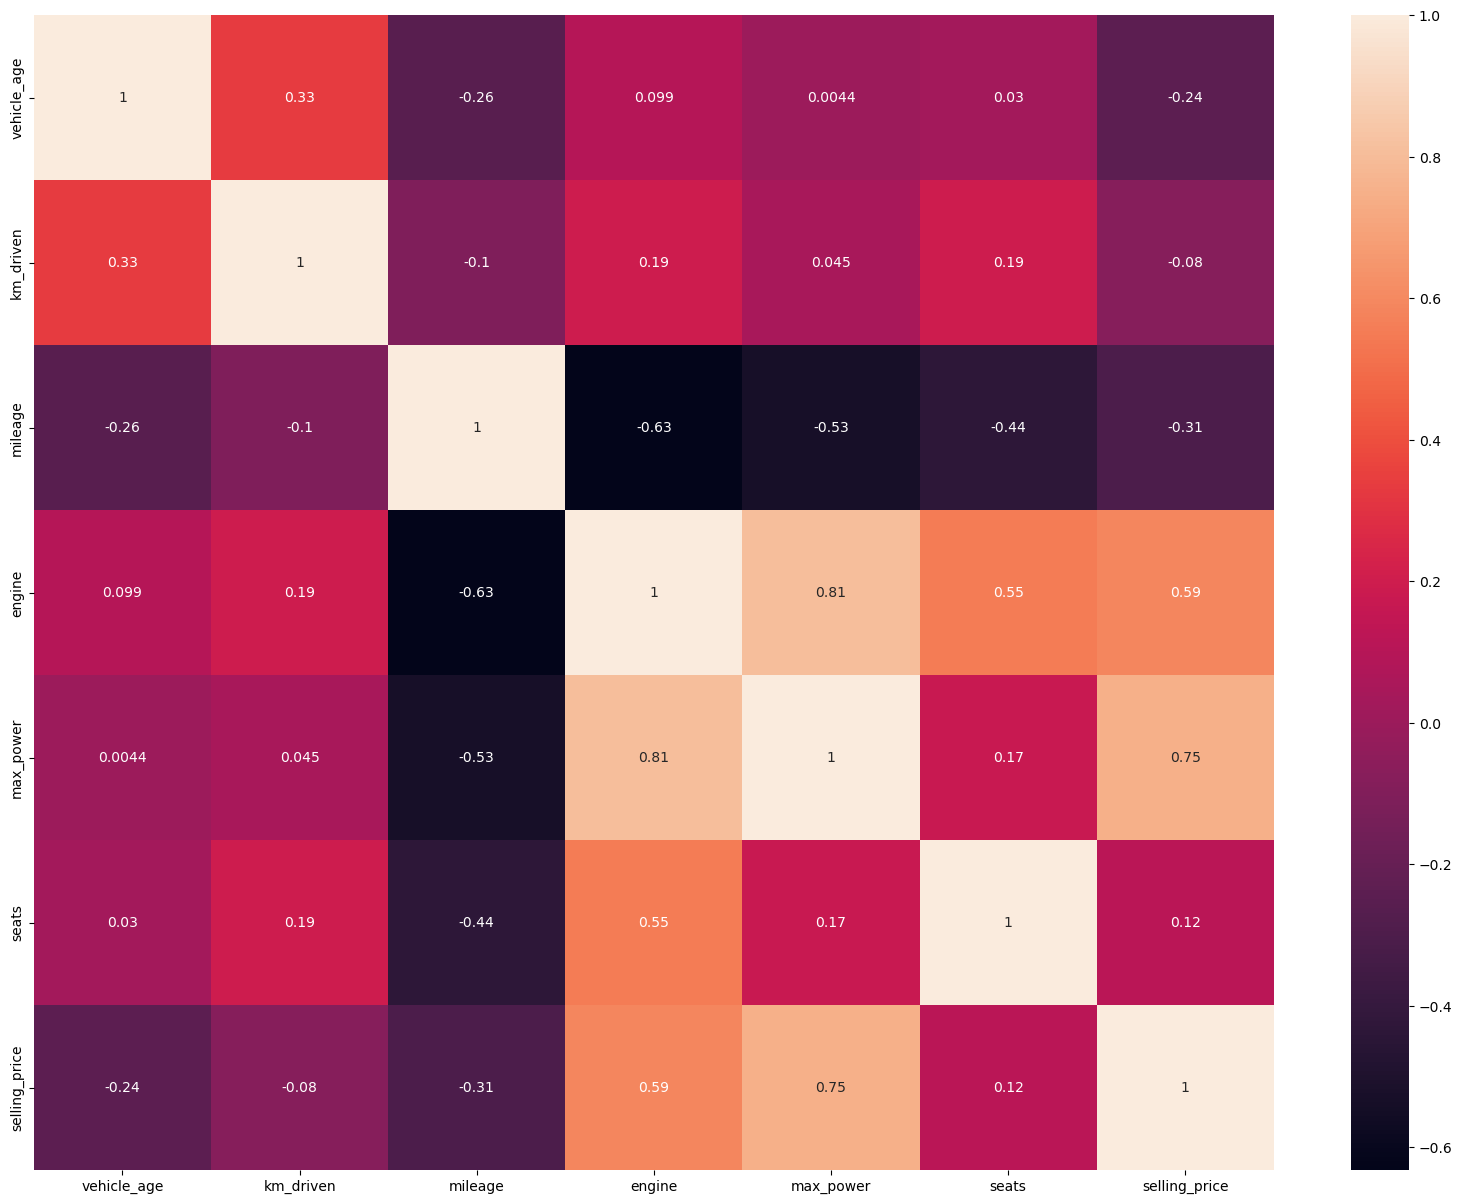

In [90]:
plt.figure(figsize=(20,15))
sns.heatmap(df[num_cols].corr(), annot=True)

In [91]:
X = df[num_cols].drop('selling_price', axis=1)
y = df['selling_price']

In [92]:
y

0         120000
1         550000
2         215000
3         226000
4         570000
          ...   
19537     250000
19540     925000
19541     425000
19542    1225000
19543    1200000
Name: selling_price, Length: 15244, dtype: int64

In [93]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [95]:
num_cols = X.select_dtypes(exclude='object').columns

In [96]:
num_transform = StandardScaler()

transformer = ColumnTransformer(
    [
        ('StandardScaler',num_transform, num_cols)
    ]
)

In [97]:
X_train = transformer.fit_transform(X_train)

In [98]:
X_test = transformer.transform(X_test)

In [99]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()

In [100]:
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [102]:
##Create a Function to Evaluate Model
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [103]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
   
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 567787.7909
- Mean Absolute Error: 276903.1875
- R2 Score: 0.6201
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 452485.4254
- Mean Absolute Error: 266153.3388
- R2 Score: 0.6633


Lasso
Model performance for Training set
- Root Mean Squared Error: 567787.7909
- Mean Absolute Error: 276902.7616
- R2 Score: 0.6201
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 452485.1246
- Mean Absolute Error: 266152.9320
- R2 Score: 0.6633


Ridge
Model performance for Training set
- Root Mean Squared Error: 567787.8017
- Mean Absolute Error: 276884.1680
- R2 Score: 0.6201
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 452478.8056
- Mean Absolute Error: 266135.6959
- R2 Score: 0.6633


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 307143.0293
- Mean 

In [104]:
#Initialize few parameter for Hyperparamter tuning
knn_params = {"n_neighbors": [2, 3, 10, 20, 40, 50]}
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}


In [105]:
from sklearn.model_selection import RandomizedSearchCV

In [106]:
rscv1 = RandomizedSearchCV(estimator=KNeighborsRegressor(), param_distributions=knn_params, n_iter=200)

In [107]:
rscv1.fit(X_train, y_train)

c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=200. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,KNeighborsRegressor()
,param_distributions,"{'n_neighbors': [2, 3, ...]}"
,n_iter,200
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [108]:
y_pred = rscv1.predict(X_test)
print(r2_score(y_test, y_pred))

0.8322911233591352


In [109]:
rscv2 = RandomizedSearchCV(estimator=RandomForestRegressor(), param_distributions=rf_params, cv=3, n_iter=100, n_jobs=-1)

In [110]:
rscv2.fit(X_train, y_train)

c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
81 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
52 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Ekangsh\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_pa

,estimator,RandomForestRegressor()
,param_distributions,"{'max_depth': [5, 8, ...], 'max_features': [5, 7, ...], 'min_samples_split': [2, 8, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [111]:
rscv2.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'max_features': 5,
 'max_depth': 15}

In [112]:
y_pred = rscv1.predict(X_test)
print(r2_score(y_test, y_pred))

0.8322911233591352


<Axes: ylabel='selling_price'>

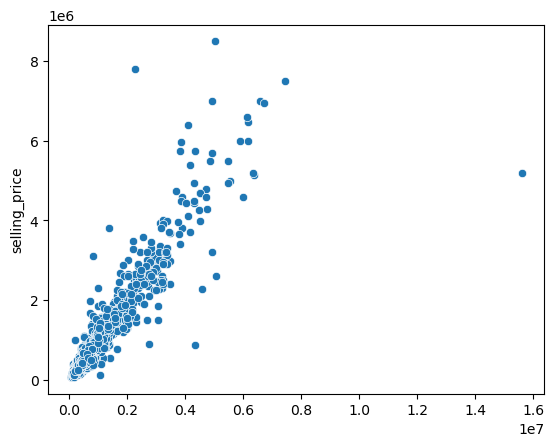

In [113]:
sns.scatterplot(x=y_pred, y = y_test)

Text(0.5, 0, 'selling price test')

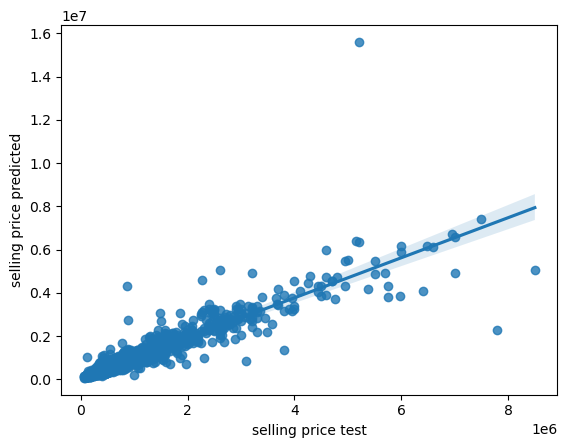

In [117]:
sns.regplot(y=y_pred, x = y_test)
plt.ylabel('selling price predicted')
plt.xlabel('selling price test')